# FreshBasket Loyalty Churn — Data Quality & EDA
Assessment 4, Tasks 1, 2 and 4. This notebook audits the three tables, shows every cleaning decision, joins them into the customer-level dataset and explores how engagement and support relate to churn. All logic lives in `src/`; the notebook calls it so results match the pipeline.

In [1]:
import sys, pandas as pd, numpy as np
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from IPython.display import Image, display
from src.data_loading import load_raw
from src.data_quality import audit_and_clean
from src.features import build_snapshot, ALL_FEATURES, FEATURE_GROUPS
from src import eda
from src.config import TEST_CUTOFF, FIG_DIR
pd.set_option('display.max_columns', 50); pd.set_option('display.width', 200)
raw = load_raw()
{k: v.shape for k, v in raw.items()}

{'profile': (2608, 10), 'activity': (28073, 12), 'label': (2605, 6)}

## 1. Raw tables

In [2]:
for k, v in raw.items():
    print(f'--- {k}'); display(v.head(3))

--- profile


,CUSTOMER_ID,SIGNUP_DATE,AGE,GENDER,CITY,MEMBERSHIP_TIER,MARKETING_OPT_IN,PREFERRED_STORE_ID,PREFERRED_CATEGORY,HOME_STORE_PRICE_TIER
0,500001,2022-08-17,36.0,F,Madison,Silver,1,140,Frozen Foods,Value
1,500002,2023-06-24,37.0,F,Spokane,Silver,0,119,Beverages,Mainstream
2,500003,2021-03-31,53.0,NaN,Tulsa,Gold,0,119,Frozen Foods,Mainstream


--- activity


,CUSTOMER_ID,MONTH,TRANSACTIONS,TOTAL_SPEND,AVG_BASKET_VALUE,DISTINCT_CATEGORIES,PROMO_TXN_PCT,APP_SESSIONS,EMAILS_OPENED,COUPONS_REDEEMED,SUPPORT_TICKETS,COMPLAINT_FLAG
0,501855,2023-03-01,5,150.01,30.00,4,0.04,3,0,1,0,0
1,501803,2024-04-01,12,325.77,27.15,3,0.12,1,2,0,0,0
2,501889,2024-05-01,4,165.54,41.38,4,0.60,4,1,0,0,0


--- label


,CUSTOMER_ID,OBSERVATION_END_DATE,LAST_PURCHASE_DATE,MONTHS_OBSERVED,INSUFFICIENT_HISTORY_FLAG,CHURNED
0,500001,2024-06-30,2024-06-01,18,0,0
1,500002,2024-06-30,2024-06-01,12,0,0
2,500003,2024-06-30,2024-06-01,18,0,0


## 2. Data-quality checks
### 2.1 Missing values

In [3]:
pd.concat({k: v.isna().sum() for k, v in raw.items()}, axis=1).fillna('').loc[lambda d: (d != 0).any(axis=1)]

,profile,activity,label
SIGNUP_DATE,0.0,,
AGE,78.0,,
GENDER,52.0,,
CITY,0.0,,
MEMBERSHIP_TIER,0.0,,
MARKETING_OPT_IN,0.0,,
PREFERRED_STORE_ID,0.0,,
PREFERRED_CATEGORY,0.0,,
HOME_STORE_PRICE_TIER,130.0,,
MONTH,,0.0,


### 2.2 Duplicates

In [4]:
p, a, l = raw['profile'], raw['activity'], raw['label']
pd.Series({'profile exact dup rows': p.duplicated().sum(),
           'activity exact dup rows': a.duplicated().sum(),
           'activity dup CUSTOMER_ID+MONTH (after exact dups dropped)': a.drop_duplicates().duplicated(['CUSTOMER_ID','MONTH']).sum(),
           'label exact dup rows': l.duplicated().sum()})

profile exact dup rows                                        8
activity exact dup rows                                      58
activity dup CUSTOMER_ID+MONTH (after exact dups dropped)     2
label exact dup rows                                          5
dtype: int64

In [5]:
# The two conflicting customer-month duplicates differ only in the sign of TOTAL_SPEND
ad = a.drop_duplicates()
ad[ad.duplicated(['CUSTOMER_ID','MONTH'], keep=False)].sort_values(['CUSTOMER_ID','MONTH'])

,CUSTOMER_ID,MONTH,TRANSACTIONS,TOTAL_SPEND,AVG_BASKET_VALUE,DISTINCT_CATEGORIES,PROMO_TXN_PCT,APP_SESSIONS,EMAILS_OPENED,COUPONS_REDEEMED,SUPPORT_TICKETS,COMPLAINT_FLAG
14414,501780,2024-05-01,3,116.18,38.73,2,0.07,6,1,0,0,0
16384,501780,2024-05-01,3,-116.18,38.73,2,0.07,6,1,0,0,0
15432,502065,2023-04-01,3,-70.32,23.44,2,0.22,0,2,1,0,0
26567,502065,2023-04-01,3,70.32,23.44,2,0.22,0,2,1,0,0


### 2.3 Inconsistent text casing

In [6]:
print(p['MEMBERSHIP_TIER'].value_counts().to_dict())
print(p['CITY'].value_counts().head(15).to_dict())

{'Silver': 1423, 'Gold': 792, 'Platinum': 289, ' Silver ': 20, 'silver': 19, 'SILVER': 18, 'GOLD': 14, ' Gold ': 12, 'PLATINUM': 9, 'gold': 8, ' Platinum ': 3, 'platinum': 1}
{'Tulsa': 287, 'Raleigh': 274, 'Columbus': 259, 'Austin': 254, 'Denver': 250, 'Madison': 245, 'Spokane': 243, 'Boise': 239, 'Nashville': 228, 'Portland': 225, 'PORTLAND': 7, ' Portland ': 6, 'AUSTIN': 5, 'BOISE': 5, ' Austin ': 5}


### 2.4 Spend errors: negative, zero and outlier values
`TOTAL_SPEND` should equal `TRANSACTIONS × AVG_BASKET_VALUE`. Checking that identity separates data-entry errors from genuine high spenders.

In [7]:
ad = ad.copy()
ad['EXPECTED'] = ad['TRANSACTIONS'] * ad['AVG_BASKET_VALUE']
ad['RATIO'] = ad['TOTAL_SPEND'] / ad['EXPECTED'].replace(0, np.nan)
print('Negative spend rows:', (ad.TOTAL_SPEND < 0).sum())
print('Zero spend with transactions > 0:', ((ad.TOTAL_SPEND == 0) & (ad.TRANSACTIONS > 0)).sum())
print('Spend > 1.5x expected (outliers):', (ad.RATIO > 1.5).sum())
ad.loc[(ad.TOTAL_SPEND < 0) | (ad.RATIO > 1.5), ['CUSTOMER_ID','MONTH','TRANSACTIONS','AVG_BASKET_VALUE','TOTAL_SPEND','EXPECTED','RATIO']].head(10)

Negative spend rows: 24
Zero spend with transactions > 0: 20
Spend > 1.5x expected (outliers): 13


,CUSTOMER_ID,MONTH,TRANSACTIONS,AVG_BASKET_VALUE,TOTAL_SPEND,EXPECTED,RATIO
731,501082,2023-09-01,10,22.69,-226.930000,226.90,-1.000132
772,500973,2024-02-01,1,31.05,-31.050000,31.05,-1.000000
890,502560,2023-10-01,8,26.63,1956.697336,213.04,9.184648
2765,501679,2024-03-01,7,35.60,-249.210000,249.20,-1.000040
4478,500160,2023-01-01,2,44.50,-89.010000,89.00,-1.000112
4646,501401,2023-05-01,4,16.75,-67.010000,67.00,-1.000149
5183,501416,2024-05-01,2,27.52,526.217600,55.04,9.560640
5344,501769,2023-03-01,1,52.38,-52.380000,52.38,-1.000000
6119,501344,2023-12-01,7,33.99,-237.960000,237.93,-1.000126
7028,501222,2023-04-01,5,20.28,-101.390000,101.40,-0.999901


### 2.5 Zero-transaction anomalies and missing months

In [8]:
z = ad[ad.TRANSACTIONS == 0]
print('Zero-transaction months:', len(z))
print('...of which report DISTINCT_CATEGORIES > 0 (impossible):', (z.DISTINCT_CATEGORIES > 0).sum())
s = ad.sort_values(['CUSTOMER_ID','MONTH'])
mi = s.MONTH.dt.year*12 + s.MONTH.dt.month
gap = (mi - mi.groupby(s.CUSTOMER_ID).shift() - 1).clip(lower=0)
print('Missing months inside a member history:', int(gap.sum()), 'across', s.loc[gap>0,'CUSTOMER_ID'].nunique(), 'members')
print('Avg transactions in the month after a gap:', round(s.loc[gap>0,'TRANSACTIONS'].mean(),2), 'vs overall', round(s.TRANSACTIONS.mean(),2))

Zero-transaction months: 2330
...of which report DISTINCT_CATEGORIES > 0 (impossible): 1452
Missing months inside a member history: 953 across 769 members
Avg transactions in the month after a gap: 4.2 vs overall 4.17


Activity right after a gap is normal, so internal gaps look like **lost records**, not inactivity: they are left as missing (excluded from averages). Months after a member's *last* record are treated as inactive, because churners' records simply stop.

### 2.6 Outlier detection: IQR method vs business-rule check
The standard Tukey IQR rule flags values beyond 1.5 x IQR from the quartiles. It is run on the raw activity table and compared with the spend-identity check used for cleaning.

In [9]:
iqr_raw = eda.iqr_outliers(raw['activity'].drop_duplicates(), eda.HIST_COLS)
iqr_raw.round(2)

,column,Q1,Q3,IQR,lower_fence,upper_fence,below_fence,above_fence,pct_flagged,max
0,TRANSACTIONS,2.00,6.00,4.00,-4.00,12.00,0,236,0.01,19.00
1,TOTAL_SPEND,58.76,188.18,129.41,-135.35,382.29,5,662,0.02,3731.42
2,AVG_BASKET_VALUE,24.66,37.00,12.34,6.15,55.51,2330,190,0.09,68.10
3,DISTINCT_CATEGORIES,1.00,4.00,3.00,-3.50,8.50,0,0,0.00,8.00
4,PROMO_TXN_PCT,0.13,0.38,0.25,-0.24,0.76,0,123,0.00,0.91
5,APP_SESSIONS,1.00,3.00,2.00,-2.00,6.00,0,534,0.02,13.00
6,EMAILS_OPENED,0.00,2.00,2.00,-3.00,5.00,0,74,0.00,9.00
7,COUPONS_REDEEMED,0.00,1.00,1.00,-1.50,2.50,0,602,0.02,8.00
8,SUPPORT_TICKETS,0.00,0.00,0.00,0.00,0.00,0,3936,0.14,4.00


In [10]:
ra = raw['activity'].drop_duplicates().copy()
q1, q3 = ra.TOTAL_SPEND.quantile([.25, .75]); hi = q3 + 1.5 * (q3 - q1)
ra['IQR_FLAG'] = (ra.TOTAL_SPEND > hi) | (ra.TOTAL_SPEND < q1 - 1.5 * (q3 - q1))
ra['IDENTITY_ERROR'] = (ra.TOTAL_SPEND / (ra.TRANSACTIONS * ra.AVG_BASKET_VALUE)).gt(1.5) | ra.TOTAL_SPEND.lt(0)
pd.crosstab(ra.IQR_FLAG, ra.IDENTITY_ERROR, rownames=['IQR flags TOTAL_SPEND'], colnames=['Spend identity broken (error)'])

Spend identity broken (error),False,True
IQR flags TOTAL_SPEND,,
False,27328,20
True,650,17


The IQR rule flags about 670 spend values, but 650 of them are **genuine heavy shoppers** (many transactions x normal basket) whose spend matches the transactions x basket identity, and it still misses 20 of the 37 broken-identity rows, because most negative-sign errors fall inside the fences. So IQR is used here to **describe** skew and tails, while the identity check decides what is an **error** to fix. Heavy-but-valid values are kept: tree models are insensitive to them and logistic regression uses scaled, aggregated features.

### 2.7 Cleaning log (everything changed, with the action taken)

In [11]:
clean, log = audit_and_clean(raw)
log

,table,check,rows_affected,action
0,profile,Exact duplicate rows,8,Dropped
1,profile,Duplicate CUSTOMER_ID with conflicting values,0,Kept first record
2,profile,CITY: inconsistent casing/whitespace,104,"Stripped whitespace, title-cased"
3,profile,MEMBERSHIP_TIER: inconsistent casing/whitespace,104,"Stripped whitespace, title-cased"
4,profile,AGE missing,78,Median-imputed at model time + AGE_MISSING flag
5,profile,AGE outside 16-100,0,Set to missing
6,profile,GENDER missing,52,Labelled 'Unknown'
7,profile,HOME_STORE_PRICE_TIER missing,130,Labelled 'Unknown'
8,activity,Exact duplicate rows,58,Dropped
9,activity,Negative TOTAL_SPEND (sign error: |spend| = tx...,24,Replaced with absolute value


### 2.8 Label validation and leakage
The official `CHURNED` is re-derived from activity (no transactions Apr–Jun 2024, purchases before). `LAST_PURCHASE_DATE`, `MONTHS_OBSERVED` and `INSUFFICIENT_HISTORY_FLAG` are computed over the full window including Apr–Jun 2024, so they leak the target and are **never used as features**.

In [12]:
lab = clean['label']
print(pd.crosstab(lab.CHURNED, lab.LAST_PURCHASE_DATE >= '2024-04-01', rownames=['CHURNED'], colnames=['LAST_PURCHASE_DATE in label window']))
lab[lab.LABEL_MISMATCH == 1][['CUSTOMER_ID','CHURNED','LAST_PURCHASE_DATE','PRE_WINDOW_TXN','LABEL_WINDOW_TXN']]

LAST_PURCHASE_DATE in label window  False  True 
CHURNED                                         
0                                     120   1662
1                                     818      0


,CUSTOMER_ID,CHURNED,LAST_PURCHASE_DATE,PRE_WINDOW_TXN,LABEL_WINDOW_TXN
650,500651,1,2023-01-01,0.0,0.0
780,500781,1,2023-01-01,0.0,0.0
1091,501092,1,2023-01-01,0.0,0.0
1185,501186,0,2024-06-01,6.0,0.0
1215,501216,1,2023-03-01,0.0,0.0
1490,501491,0,2024-05-01,20.0,0.0
1923,501924,1,2023-04-01,0.0,0.0
2007,502008,0,2024-04-01,72.0,0.0
2023,502024,0,2024-04-01,43.0,0.0


`LAST_PURCHASE_DATE` alone would reproduce the label almost perfectly (the 120 members it misses never purchased at all), which is exactly why it must be excluded.

## 3. Join: customer-level modelling dataset
Profile + monthly activity (aggregated using only months up to March 2024) + official label. Members with no purchase before April 2024 are outside the churn definition (cold start) and are not scored.

In [13]:
snap = build_snapshot(clean, TEST_CUTOFF)
print(snap.shape, '| churn rate', round(snap.CHURNED.mean(), 3))
print('Cold-start members not scored:', int(lab.NO_PRE_WINDOW_HISTORY.sum()))
{g: len(f) for g, f in FEATURE_GROUPS.items()}

(2368, 46) | churn rate 0.343
Cold-start members not scored: 232


{'demographic': 10, 'behavioural': 17, 'engagement': 8, 'support': 5}

In [14]:
snap[['CUSTOMER_ID'] + ALL_FEATURES + ['ACTIVE_AT_CUTOFF','CHURNED']].head()

,CUSTOMER_ID,AGE,AGE_MISSING,GENDER,CITY,MEMBERSHIP_TIER,MARKETING_OPT_IN,PREFERRED_CATEGORY,HOME_STORE_PRICE_TIER,SIGNUP_YEAR,TENURE_MONTHS,RECENCY_MONTHS,HISTORY_MONTHS,ACTIVE_MONTH_RATIO,MISSING_MONTHS,TXN_L1,TXN_L3,TXN_P3,TXN_TREND,TXN_ALL_MEAN,SPEND_L3,SPEND_P3,SPEND_TREND_PCT,SPEND_ALL_MEAN,SPEND_CV,BASKET_L3,CATEGORIES_L3,ZERO_TXN_MONTHS_L3,PROMO_PCT_L3,PROMO_PCT_ALL,APP_L3,APP_TREND,EMAIL_L3,EMAIL_TREND,COUPON_L3,COUPON_ALL_MEAN,TICKETS_L3,TICKETS_L6,TICKETS_TREND,COMPLAINTS_L6,COMPLAINT_EVER,ACTIVE_AT_CUTOFF,CHURNED
0,500001,36.0,0,F,Madison,Silver,1,Frozen Foods,Value,2022,19,0.0,15,1.000000,1,8.0,7.000000,3.500000,3.500000,4.857143,146.093333,81.510000,0.782733,108.057143,0.327308,20.870476,3.666667,0,0.190000,0.197143,1.666667,0.666667,0.333333,-0.166667,0.666667,0.500000,0.0,1.0,-1.0,1.0,1,1,0
1,500002,37.0,0,F,Spokane,Silver,0,Beverages,Mainstream,2023,9,0.0,9,1.000000,0,2.0,4.000000,6.333333,-2.333333,5.888889,119.036667,210.476667,-0.432388,199.155556,0.368583,29.759167,1.000000,0,0.236667,0.307778,1.666667,-1.000000,0.333333,0.000000,1.000000,0.555556,0.0,0.0,0.0,0.0,0,1,0
2,500003,53.0,0,Unknown,Tulsa,Gold,0,Frozen Foods,Mainstream,2021,36,0.0,15,1.000000,1,9.0,4.666667,3.333333,1.333333,4.928571,163.163333,120.310000,0.353255,156.967857,0.472608,34.963571,2.000000,0,0.366667,0.342143,2.000000,-1.000000,0.333333,0.333333,0.000000,0.714286,2.0,2.0,2.0,1.0,1,1,0
3,500004,52.0,0,F,Spokane,Gold,1,Snacks,Upscale,2021,32,0.0,15,1.000000,1,5.0,5.333333,4.500000,0.833333,5.357143,122.663333,110.565000,0.108442,127.053571,0.397253,22.999375,3.666667,0,0.140000,0.243571,3.333333,-3.166667,1.666667,1.166667,1.000000,0.642857,0.0,0.0,0.0,0.0,1,1,0
4,500006,44.0,0,F,Nashville,Silver,0,Snacks,Upscale,2022,18,1.0,15,0.933333,0,0.0,1.333333,3.333333,-2.000000,2.466667,38.836667,120.686667,-0.672629,80.830000,0.817863,29.127500,0.666667,1,0.255000,0.284286,2.000000,-1.666667,0.666667,0.666667,1.000000,0.400000,2.0,3.0,1.0,0.0,0,1,0


## 4. Exploratory analysis

### 4.0 Target balance

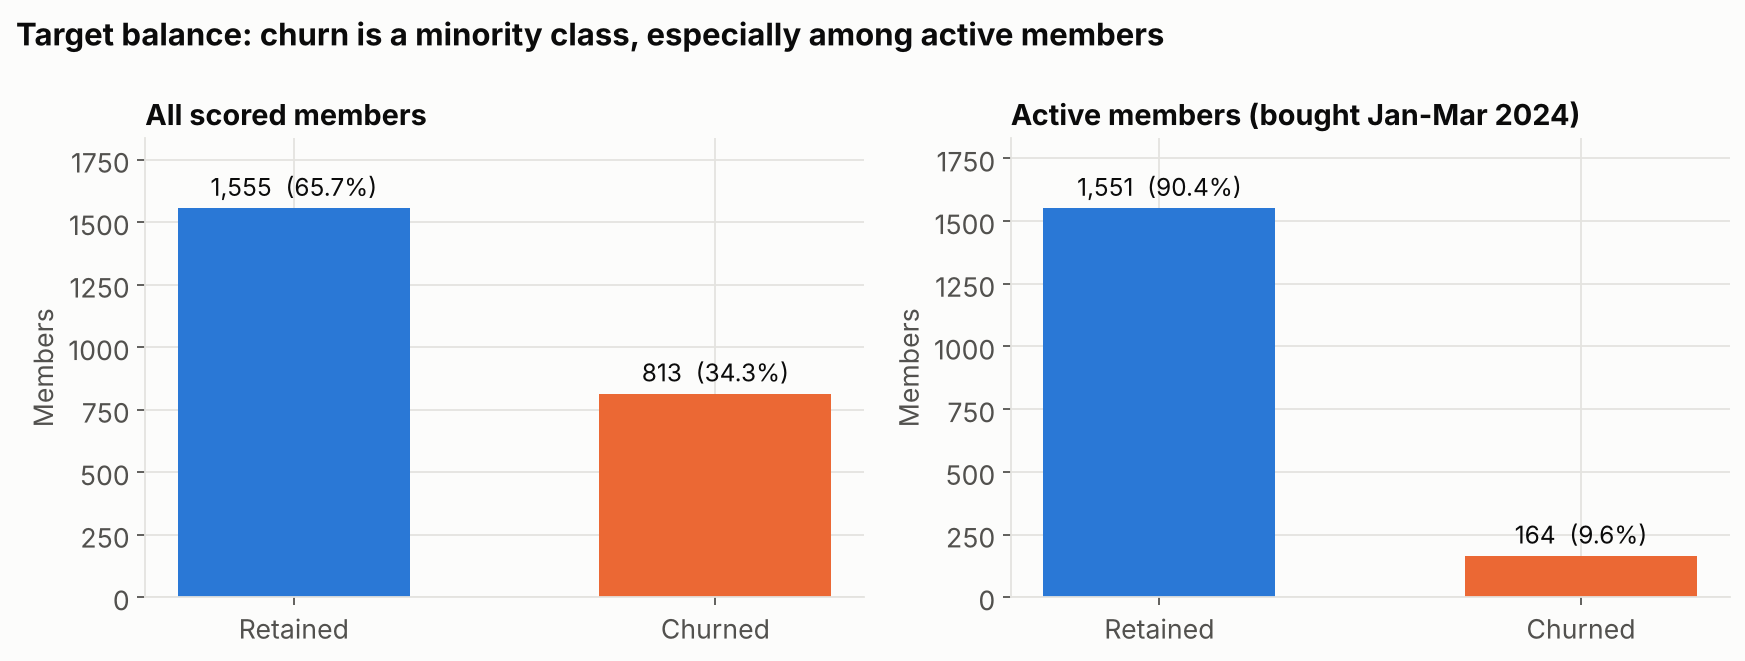

In [15]:
display(Image(eda.fig_target_balance(snap)))

Churn is the minority class (about 1 in 3 overall, under 1 in 10 among active members), so accuracy alone would be misleading. Models are judged on precision, recall, F1 and PR-AUC.

### 4.0b Univariate distributions (histograms)

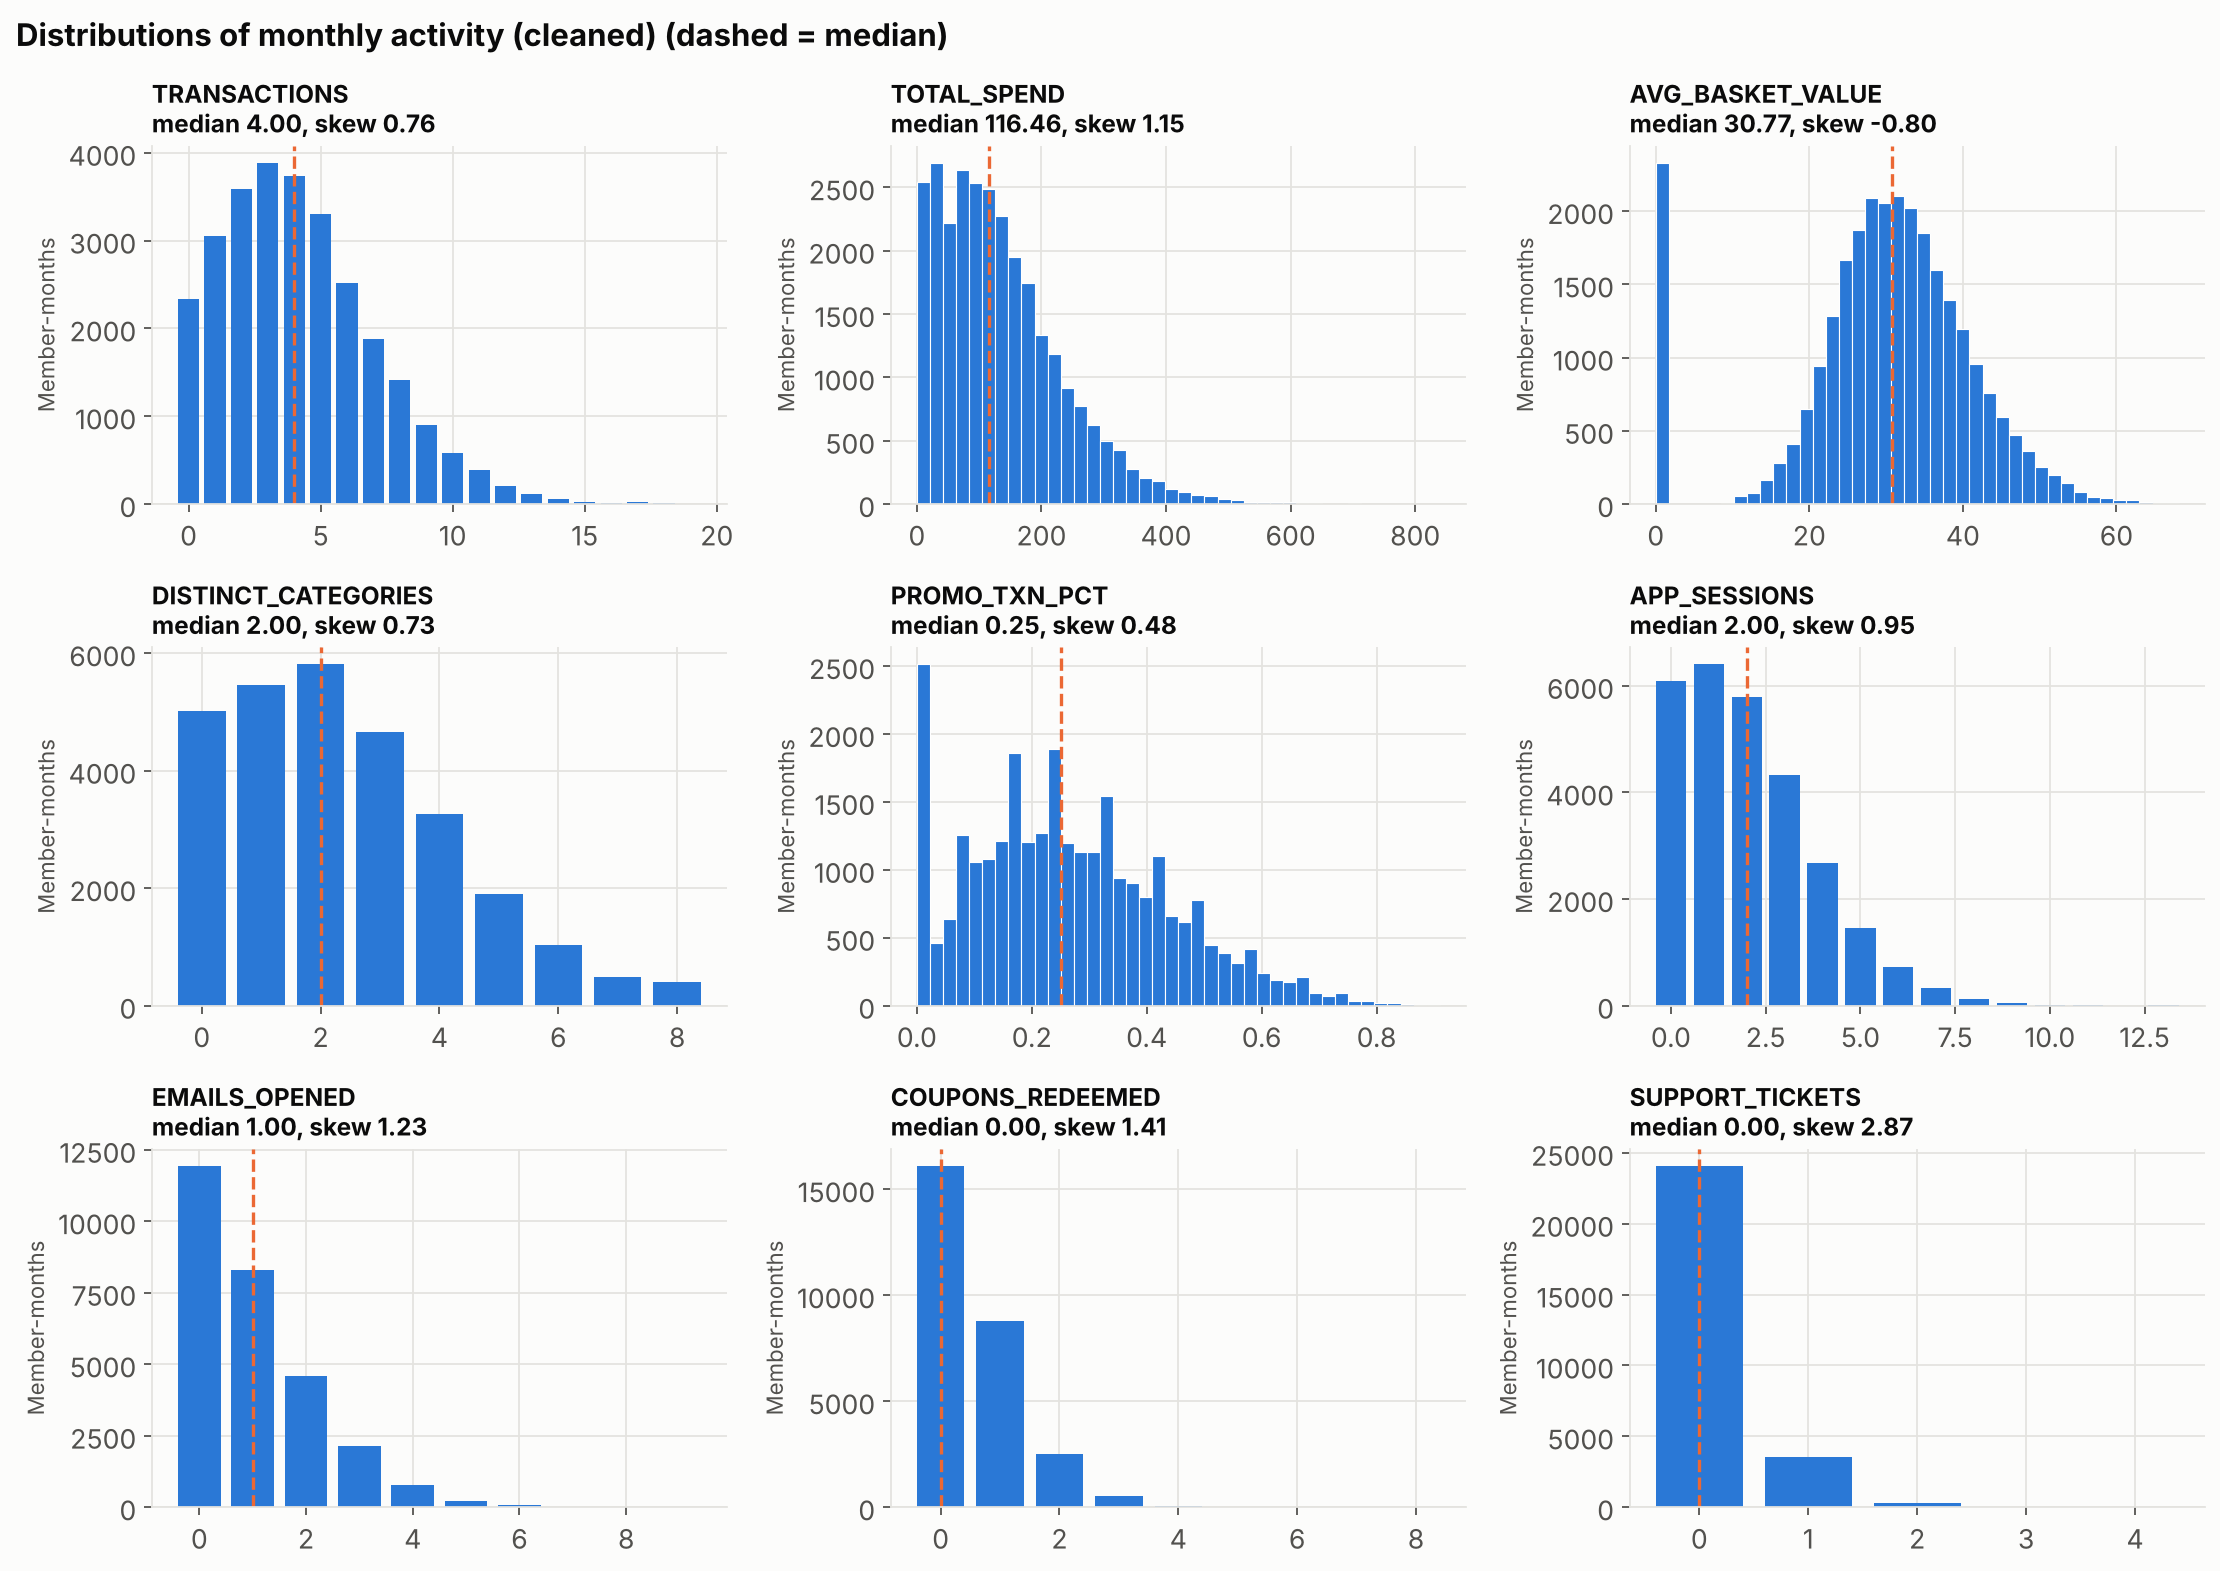

,count,mean,std,min,25%,50%,75%,max
TRANSACTIONS,28013.0,4.17,2.90,0.0,2.00,4.00,6.00,19.00
TOTAL_SPEND,28013.0,134.23,101.54,0.0,58.97,116.46,188.15,839.51
AVG_BASKET_VALUE,28013.0,29.64,12.05,0.0,24.66,30.77,37.00,68.10
DISTINCT_CATEGORIES,28013.0,2.37,1.88,0.0,1.00,2.00,4.00,8.00
PROMO_TXN_PCT,28013.0,0.26,0.17,0.0,0.13,0.25,0.38,0.91
APP_SESSIONS,28013.0,2.05,1.77,0.0,1.00,2.00,3.00,13.00
EMAILS_OPENED,28013.0,1.02,1.16,0.0,0.00,1.00,2.00,9.00
COUPONS_REDEEMED,28013.0,0.56,0.76,0.0,0.00,0.00,1.00,8.00
SUPPORT_TICKETS,28013.0,0.16,0.41,0.0,0.00,0.00,0.00,4.00


In [16]:
display(Image(eda.fig_histograms(clean['activity'])))
clean['activity'][eda.HIST_COLS].describe().T.round(2)

Spend, app sessions, emails, coupons and support tickets are **right-skewed** with many zeros; basket value is roughly bell-shaped apart from the spike at 0 from zero-purchase months. Skewed counts are summarised as rolling means and trends per member, and logistic regression standardises them.

### 4.1 Churn develops gradually

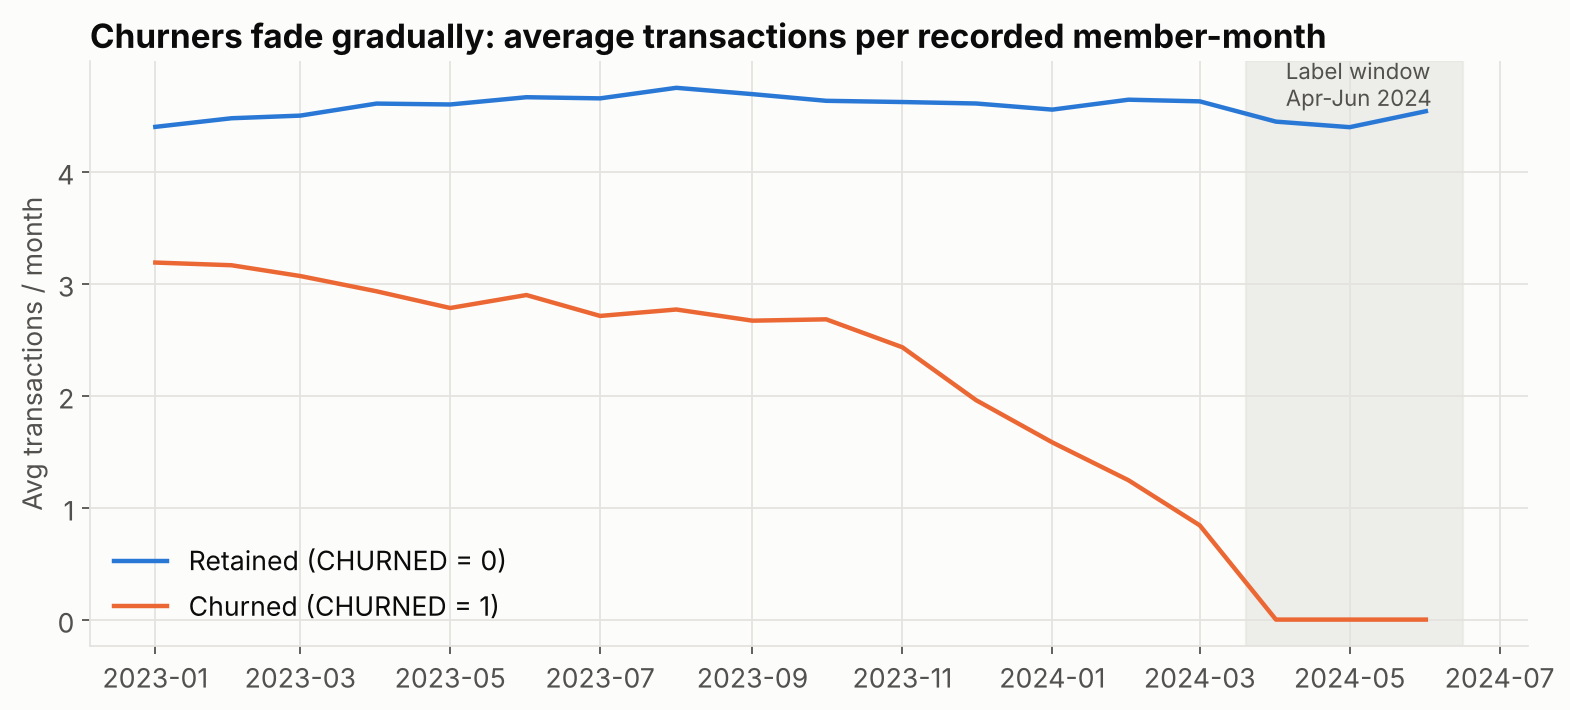

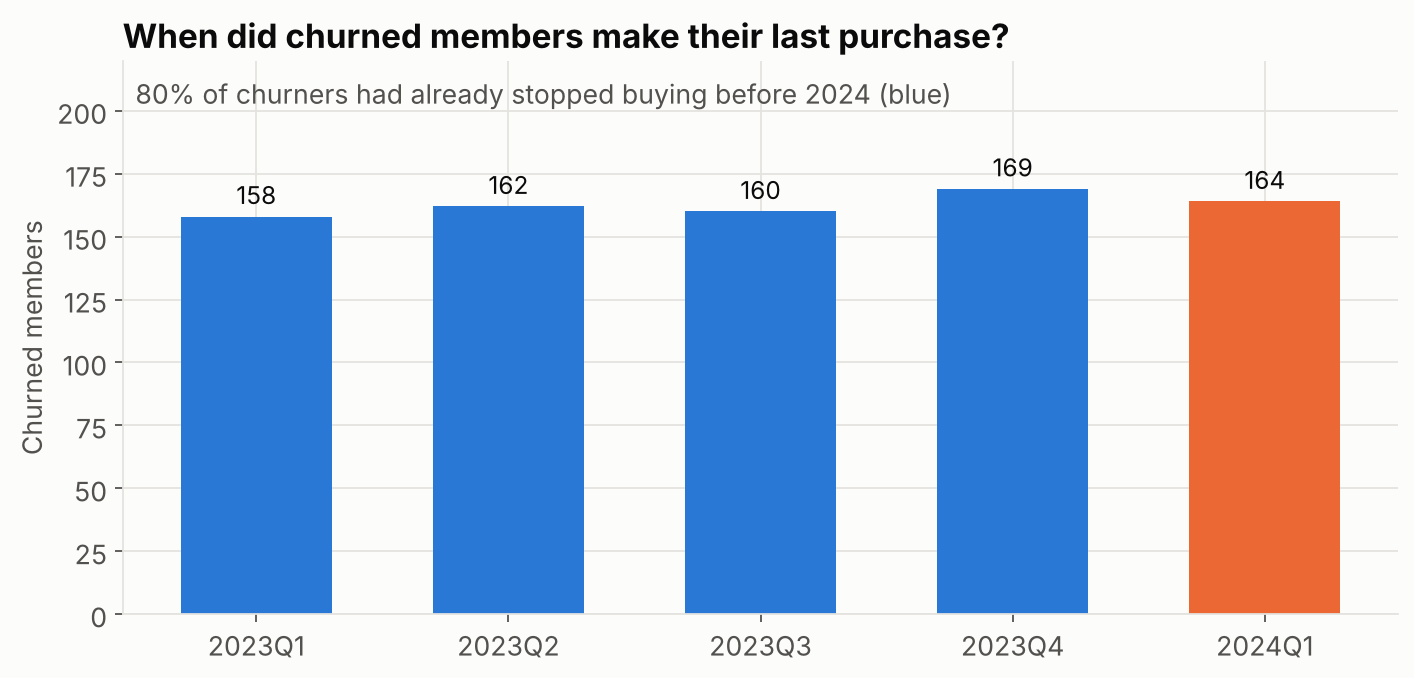

Lapsed before 2024: 79.8%


In [17]:
display(Image(eda.fig_monthly_trend(clean['activity'], lab)))
path, share = eda.fig_last_purchase(lab, clean['activity'])
display(Image(path)); print(f'Lapsed before 2024: {share:.1%}')

About four in five churners had already stopped buying before 2024. For them, recency alone predicts the label. The useful retention problem is the **active** members (bought in Jan–Mar 2024), whose churn rate is about 10%. Results are reported for both groups.

In [18]:
snap.groupby('ACTIVE_AT_CUTOFF').CHURNED.agg(['size','mean'])

,size,mean
ACTIVE_AT_CUTOFF,,
0,653,0.993874
1,1715,0.095627


### 4.2 Churn by segment (tier, cohort, city)

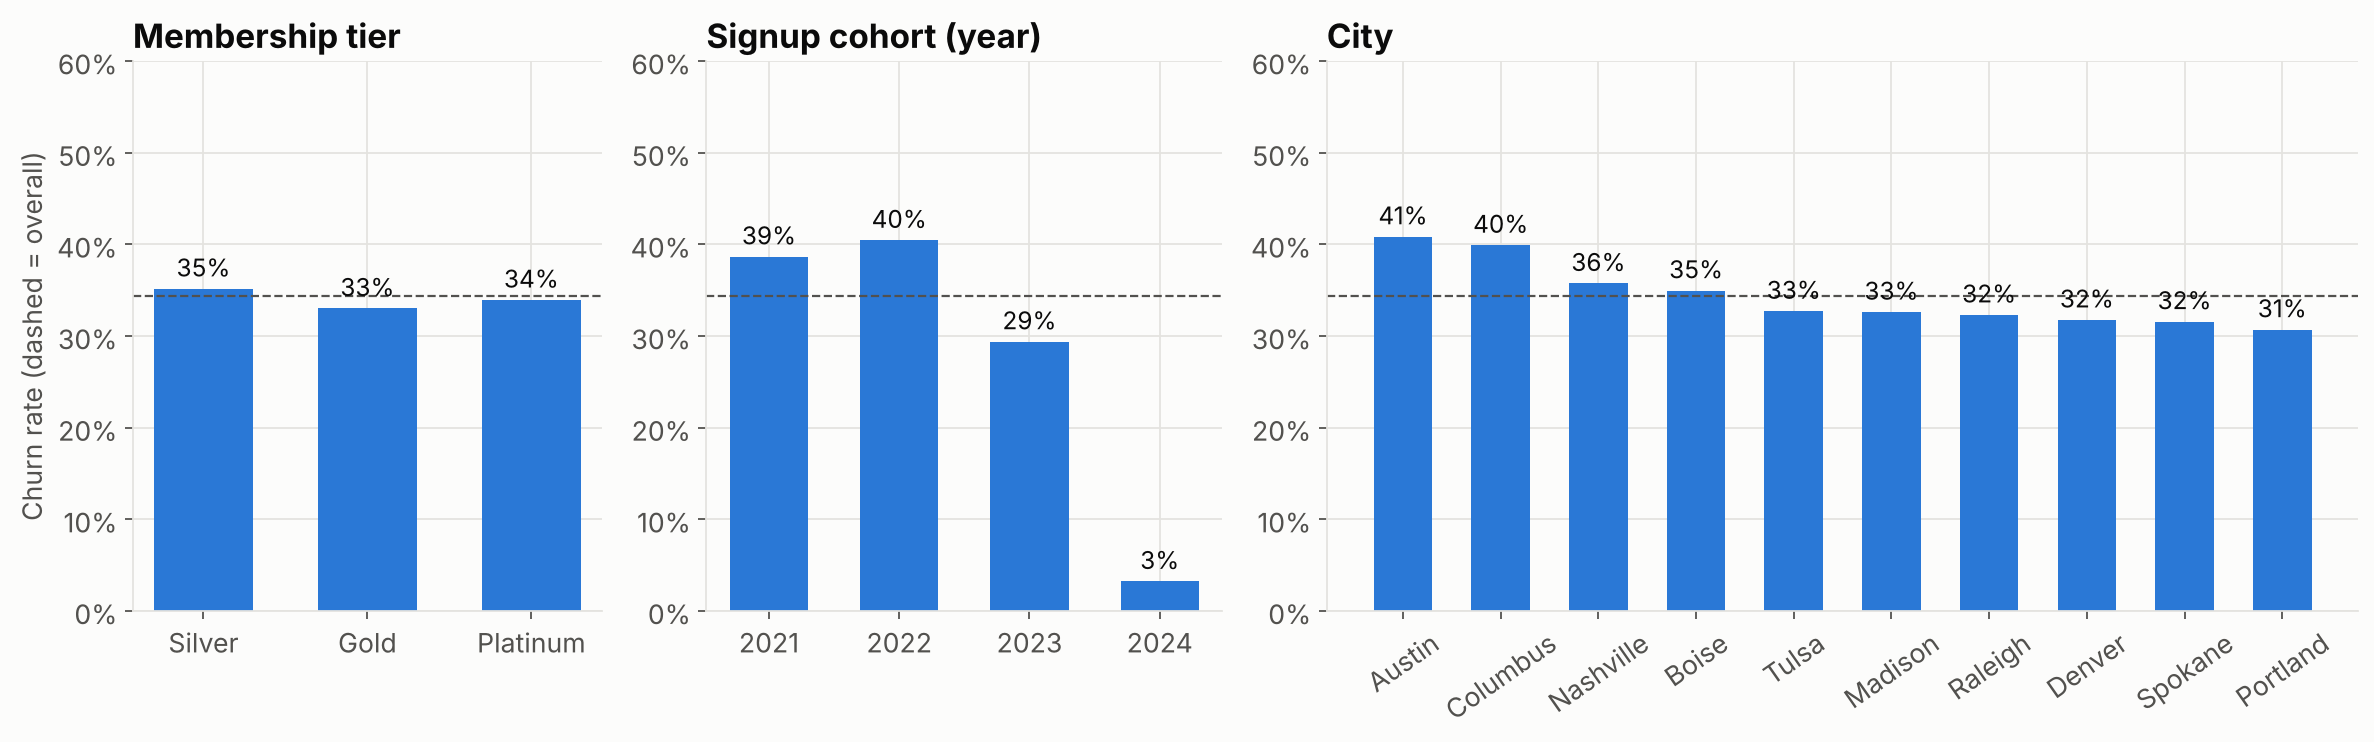

,churn_rate,members
MEMBERSHIP_TIER,,
Silver,0.351493,1340
Gold,0.330226,751
Platinum,0.339350,277


In [19]:
path, tables = eda.fig_segments(snap)
display(Image(path))
tables['MEMBERSHIP_TIER']

### 4.3 Behaviour profile: churned vs retained (active members)

In [20]:
act = snap[snap.ACTIVE_AT_CUTOFF == 1]
act.groupby('CHURNED')[['TXN_L1','TXN_L3','TXN_TREND','SPEND_L3','SPEND_TREND_PCT','APP_L3','EMAIL_L3','COUPON_L3','PROMO_PCT_L3','TICKETS_L3','COMPLAINTS_L6','TENURE_MONTHS']].mean().T.round(2)

CHURNED,0,1
TXN_L1,4.52,0.55
TXN_L3,4.60,1.35
TXN_TREND,-0.05,-1.88
SPEND_L3,148.24,43.66
SPEND_TREND_PCT,0.36,-0.06
APP_L3,2.27,0.58
EMAIL_L3,1.09,0.43
COUPON_L3,0.61,0.21
PROMO_PCT_L3,0.29,0.34
TICKETS_L3,0.33,1.02


### 4.3b Box plots: churned vs retained (active members)

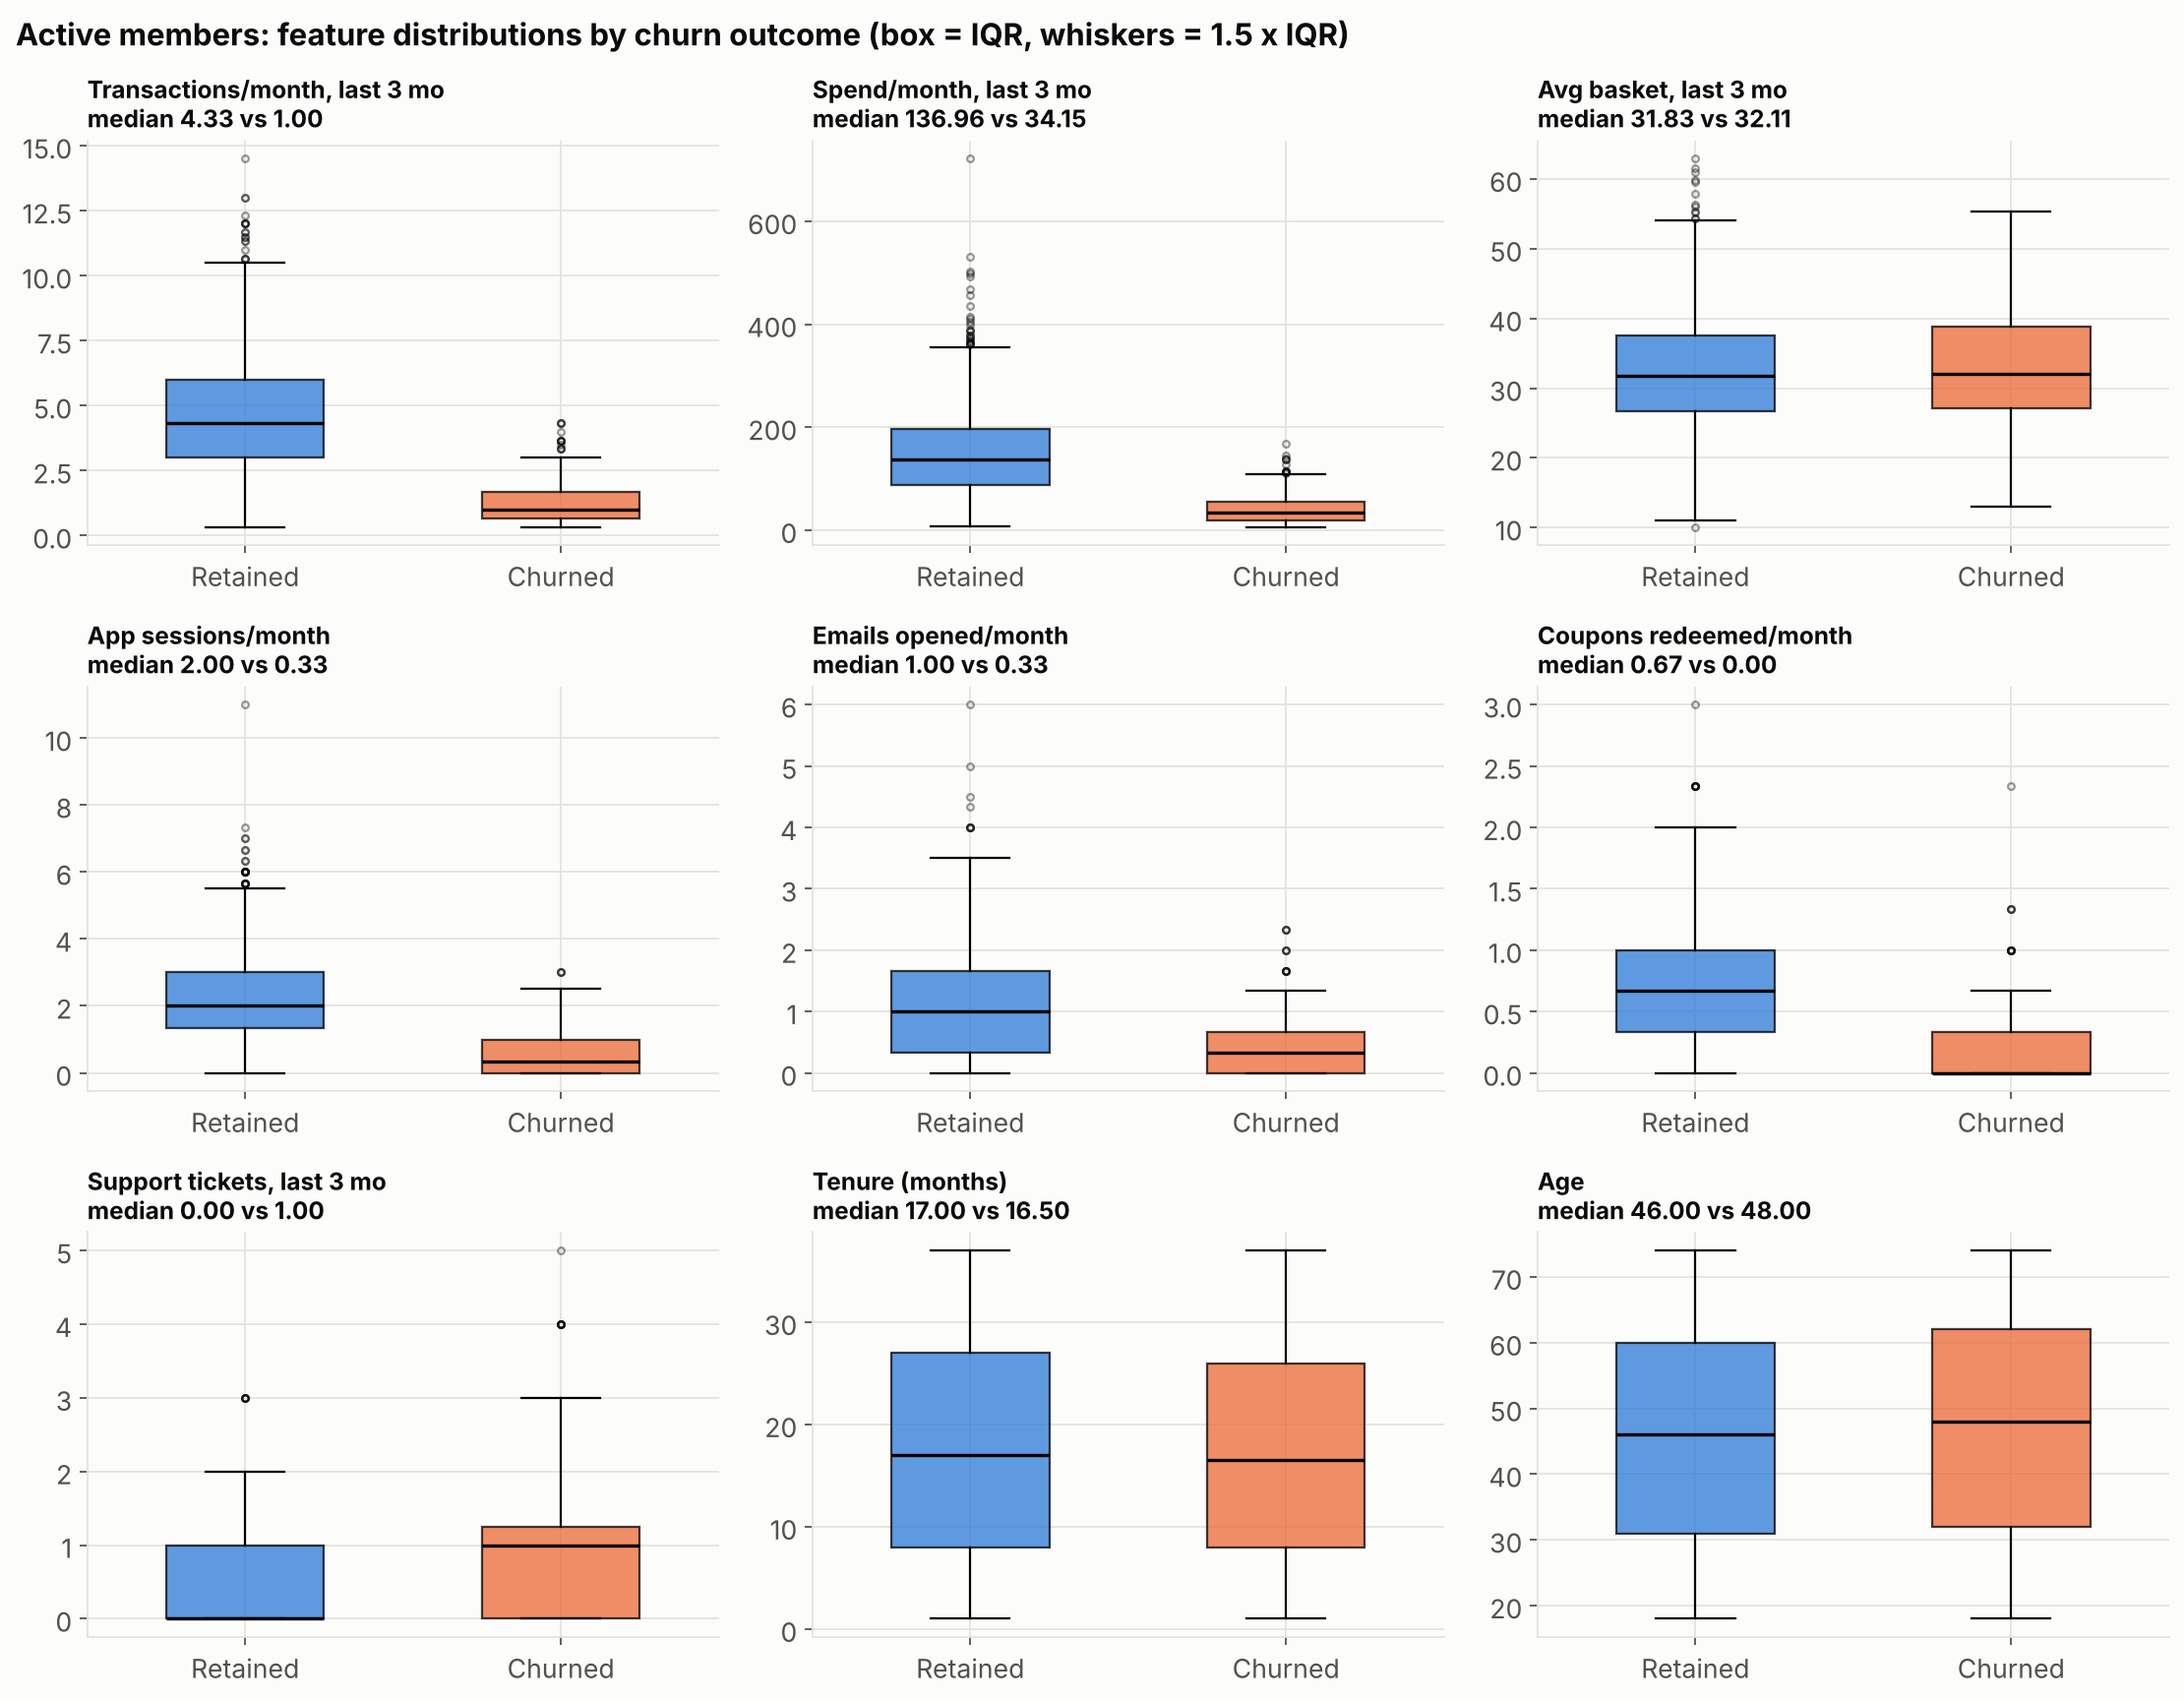

In [21]:
display(Image(eda.fig_boxplots_by_churn(snap)))

Churners buy less often, spend less, use the app and open emails less, redeem fewer coupons and raise more support tickets. Basket size, tenure and age overlap heavily between the groups, so they separate churners poorly.

### 4.4 Engagement, support experience and churn (Task 4)

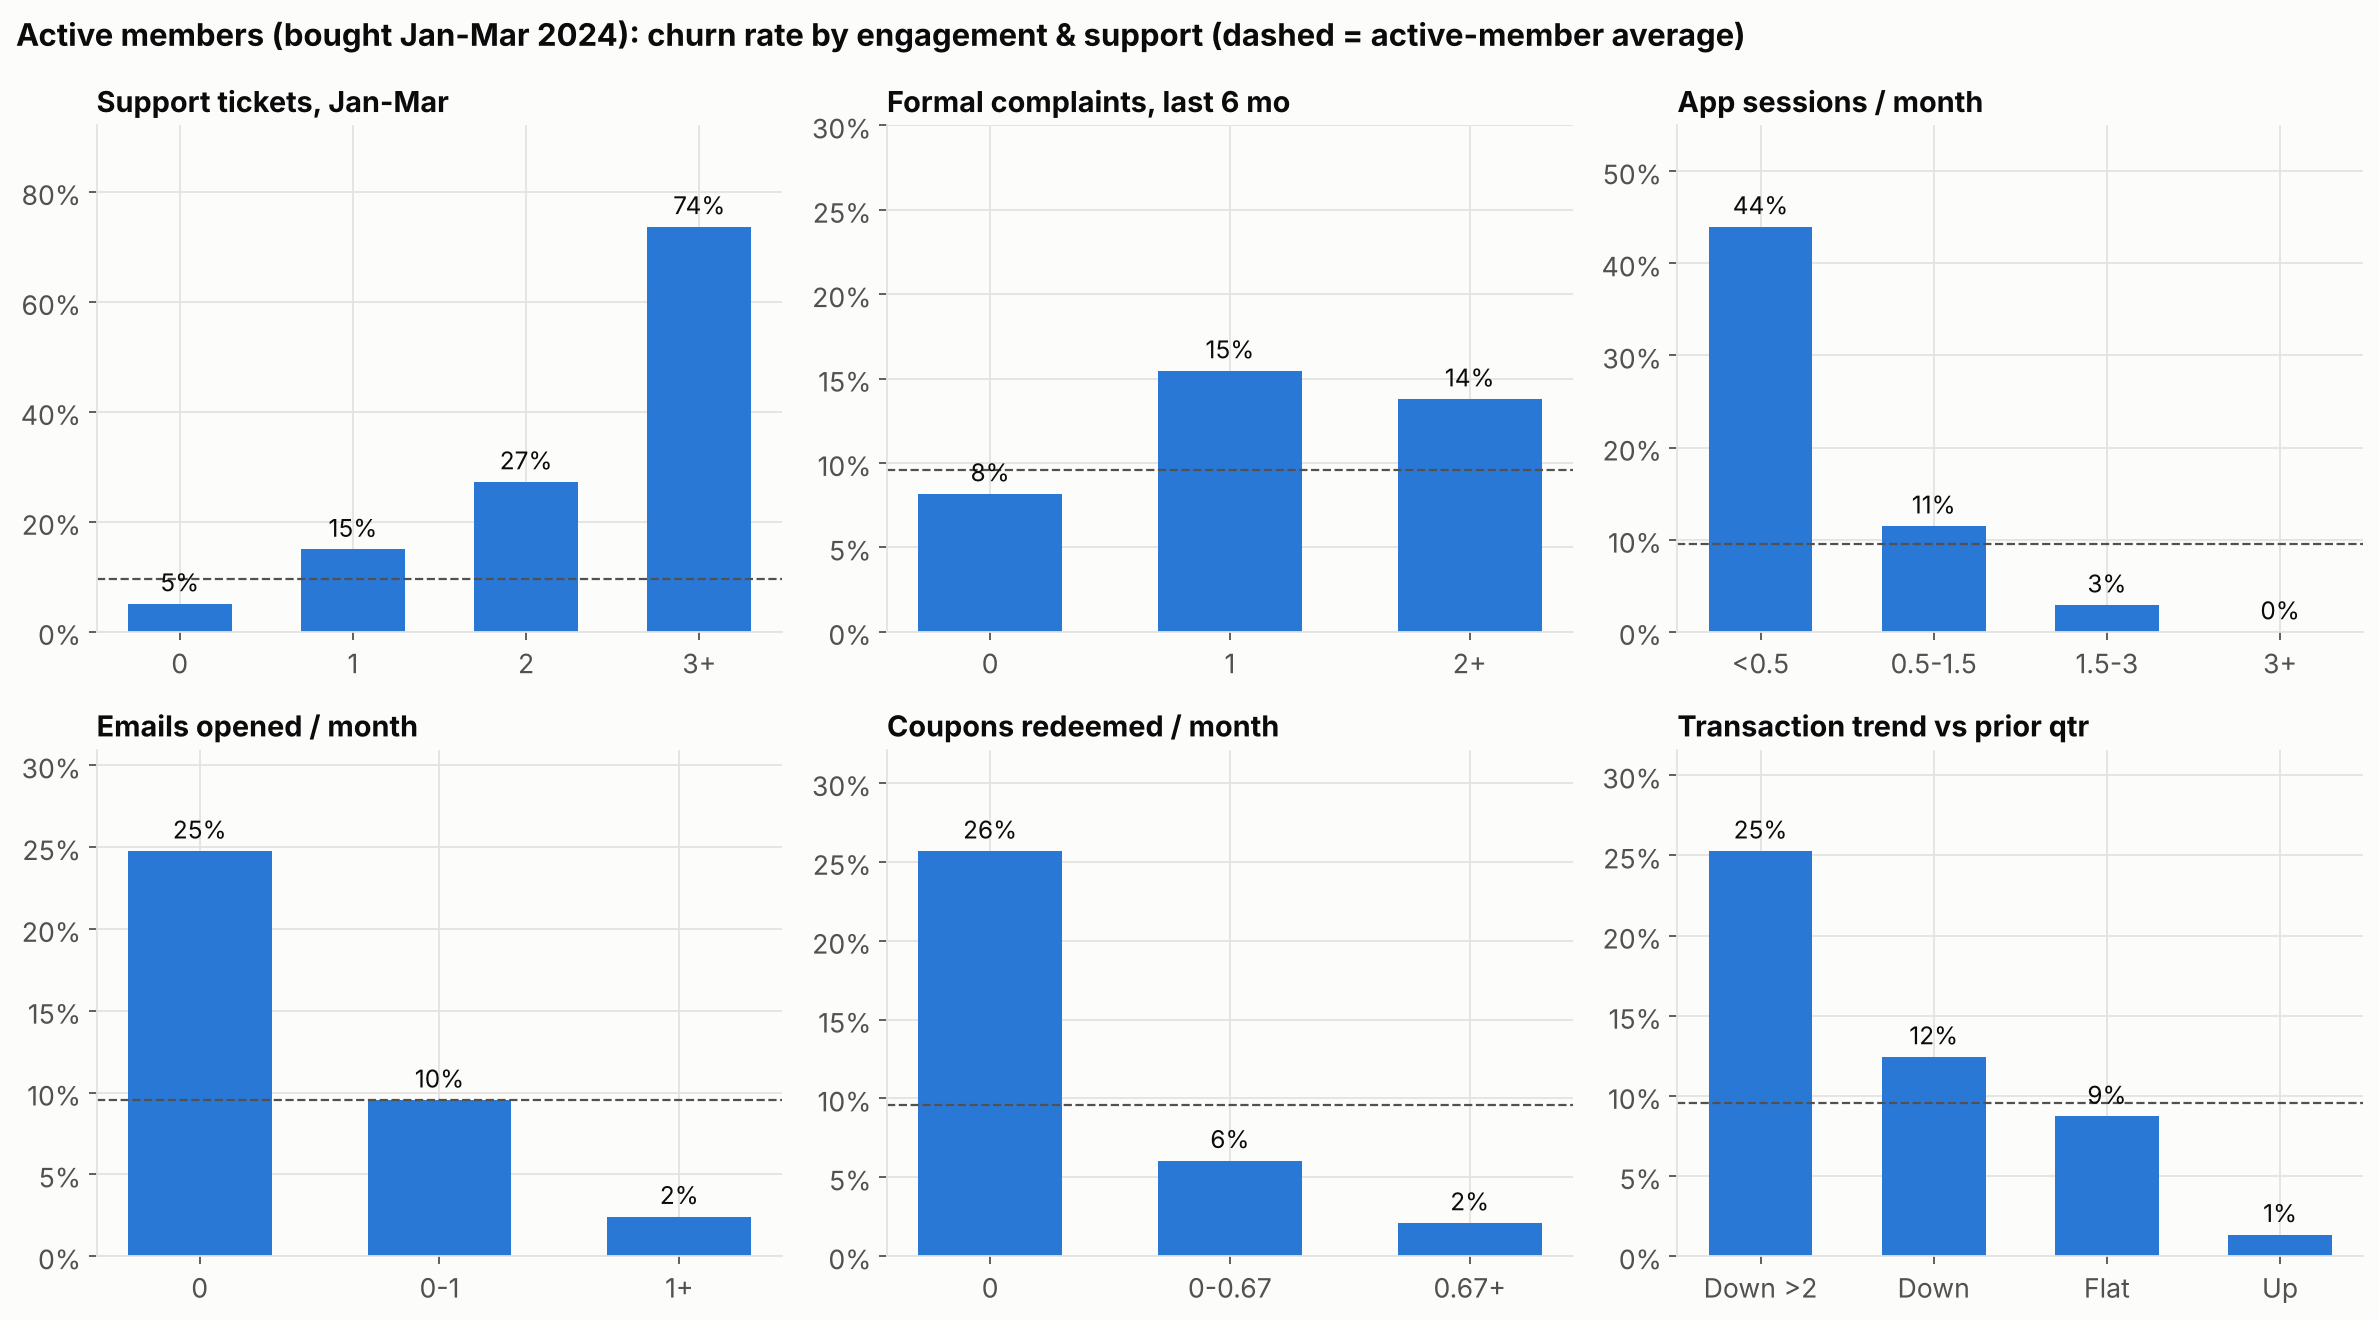

,Spearman with churn (active)
APP_L3,-0.385
SPEND_TREND_PCT,-0.342
COUPON_L3,-0.276
TXN_TREND,-0.274
EMAIL_L3,-0.250
APP_TREND,-0.207
EMAIL_TREND,-0.181
MARKETING_OPT_IN,-0.047
COMPLAINTS_L6,0.095
PROMO_PCT_L3,0.109


In [22]:
path, rel, corr = eda.engagement_support_relationship(snap)
display(Image(path))
corr.round(3).to_frame('Spearman with churn (active)')

### 4.5 Feature correlation (redundancy check)

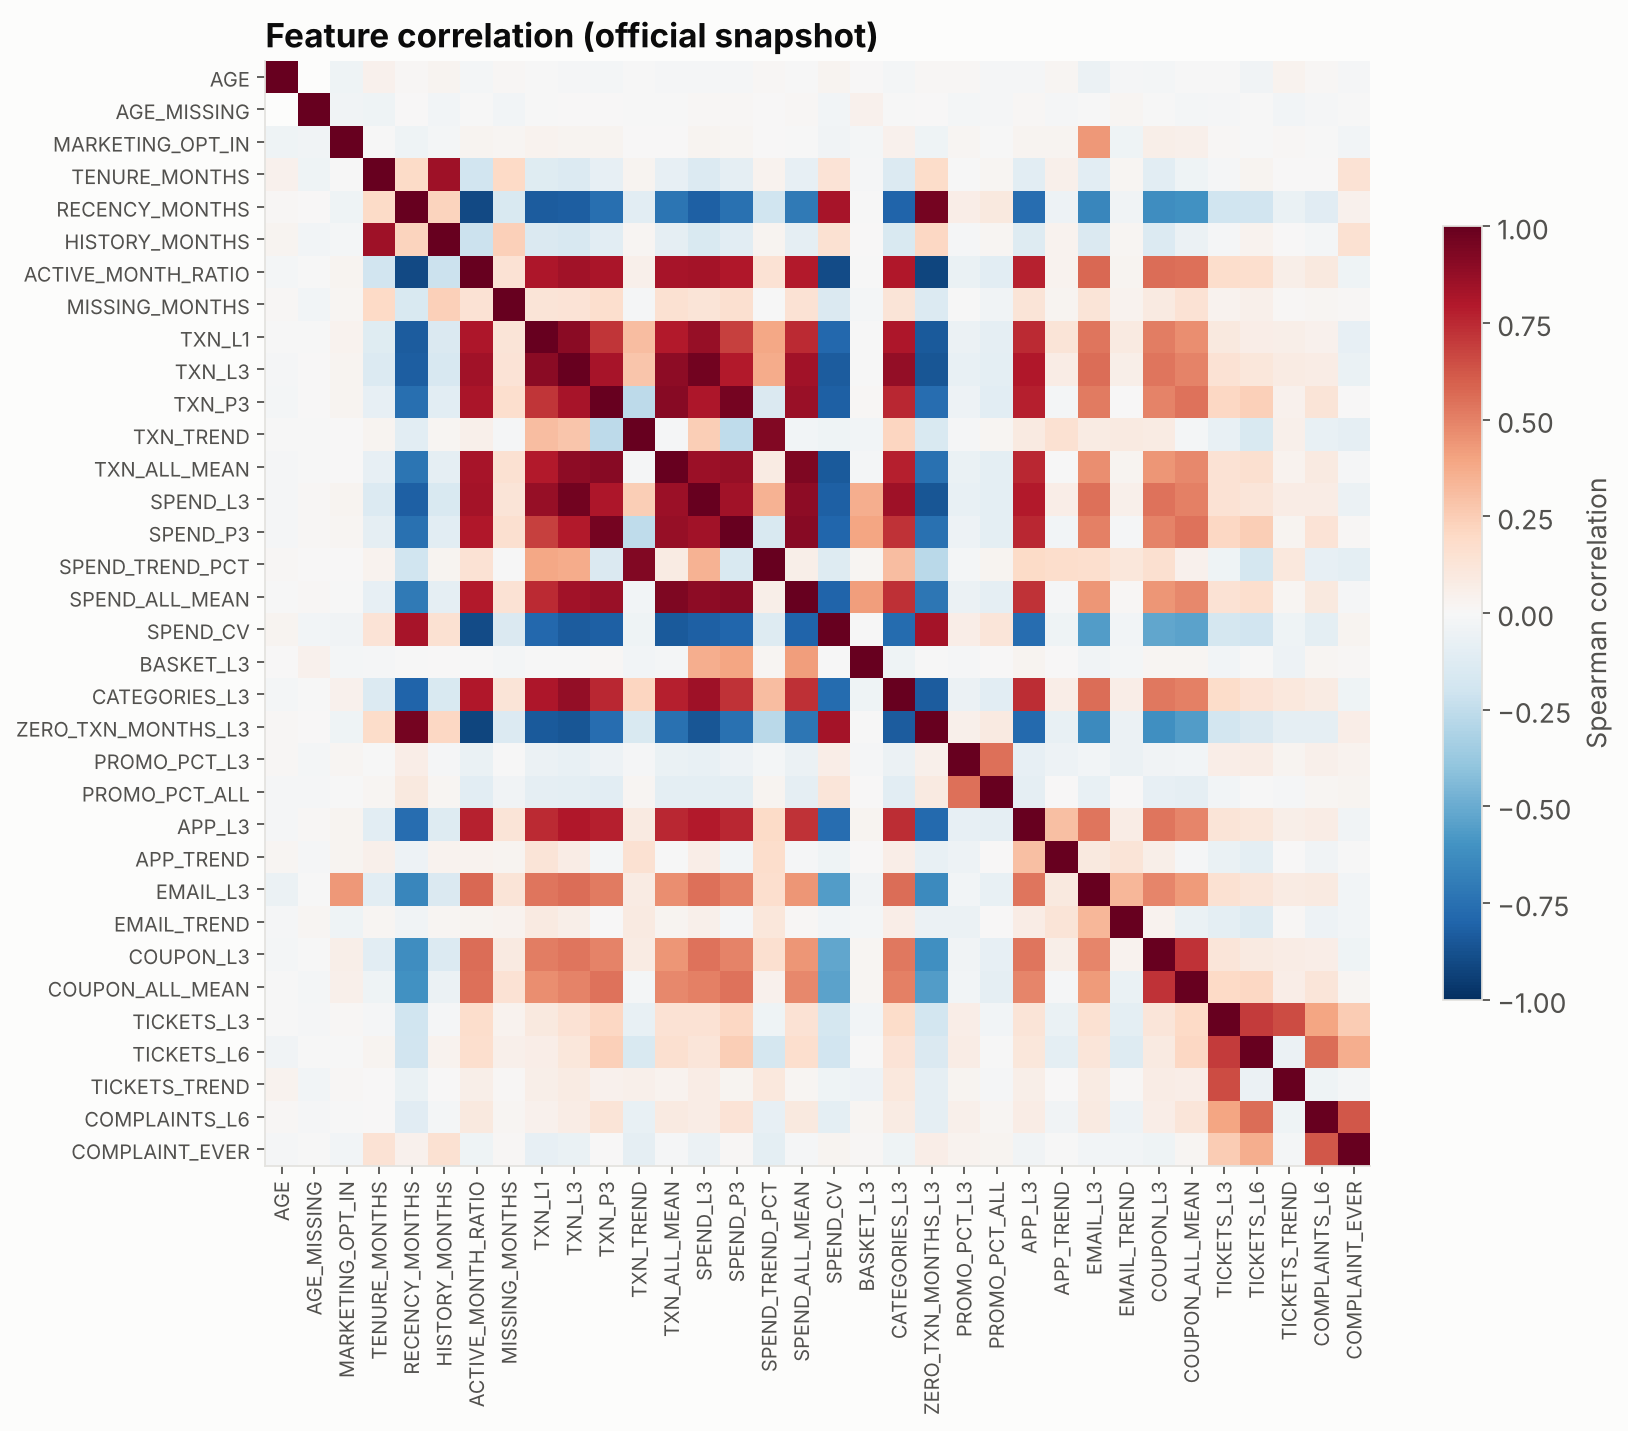

In [23]:
num = [c for c in ALL_FEATURES if c not in ['GENDER','CITY','MEMBERSHIP_TIER','PREFERRED_CATEGORY','HOME_STORE_PRICE_TIER','SIGNUP_YEAR']]
display(Image(eda.fig_correlation(snap, num)))

## 5. Key EDA findings
1. **Data issues fixed:** duplicate rows in all three tables, casing/whitespace in city and tier, negative/zero/outlier spend (repaired from the transactions × basket identity), impossible category counts in zero-purchase months, missing months, and missing age/gender/price tier.
2. **Leakage:** three label-table columns encode the outcome and are excluded.
3. **Two populations:** most churners lapsed long before the label window; active-member churn (~10%) is the actionable problem.
4. **Engagement matters most:** low app use, no email opens and no coupon redemption go with much higher churn.
5. **Distributions:** most activity measures are right-skewed with many zeros; IQR describes the tails, but only the spend-identity check identifies errors.
6. **Support friction is a warning sign:** churn rises steeply with support tickets in the last quarter (about 5% with none, about 74% with three or more among active members); formal complaints roughly double risk.
7. **Tier and city differences are small**; newer signup cohorts behave differently from 2021–2022 cohorts.
These are associations, not causal effects.